# SPARROW DLPFC Example: Sample 151673

This tutorial runs a compact single-sample SPARROW workflow for DLPFC Visium sample `151673`: clustering, inspection of precomputed deconvolution output, and a minimal spatial A-to-I analysis. It is intended as the lightweight GitHub example; the full reproduction notebooks and large data files should be archived separately with the dataset.

All figures are displayed in the notebook only; no files are written.

Results are displayed inline. This notebook does not export figures or result files.


## Setup

The example expects a local copy of the sample data directory containing the 10x Visium matrix, spatial image files, manual layer labels, precomputed deconvolution output, and the A-to-I AnnData object. Set `SPARROW_DLPFC_151673_DIR` to that directory, or edit `SAMPLE_DIR` below.

The optional mclust section uses the R installation inside the active `sparrow` conda environment through `rpy2`.


In [24]:
from pathlib import Path
import json
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Make conda-env R visible to rpy2 before importing SPARROW utilities.
R_HOME = Path(sys.prefix) / "lib" / "R"
if not R_HOME.exists():
    R_HOME = Path(sys.prefix) / "Lib" / "R"
if not R_HOME.exists():
    raise RuntimeError("Conda-environment R was not found. Install r-base in the active SPARROW environment.")

R_DLL_DIRS = [
    Path(sys.prefix) / "Library" / "mingw-w64" / "bin",
    Path(sys.prefix) / "Library" / "bin",
    R_HOME / "bin" / "x64",
    R_HOME / "bin",
    Path(sys.prefix) / "Scripts",
]
for dll_dir in R_DLL_DIRS:
    if dll_dir.exists() and hasattr(os, "add_dll_directory"):
        os.add_dll_directory(str(dll_dir))

os.environ["R_HOME"] = str(R_HOME)
os.environ["PATH"] = os.pathsep.join(str(p) for p in R_DLL_DIRS if p.exists()) + os.pathsep + os.environ.get("PATH", "")

from sparrow import SPARROW
from sparrow import atoi
from sparrow.preprocess import *
from sparrow.utils import *

warnings.filterwarnings("ignore")

# Display results only; disable automatic figure export from earlier sessions.
sc.settings.autosave = False
sc.settings.autoshow = True
if "_SPARROW_ORIGINAL_PLT_SHOW" in globals():
    plt.show = _SPARROW_ORIGINAL_PLT_SHOW


SAMPLE_ID = "151673"
SAMPLE_DIR = Path(os.environ.get("SPARROW_DLPFC_151673_DIR", "D:/data/SPARROW_data/DLPFC/151673"))
GROUP_KEY = "ground_truth"
RANDOM_SEED = 42

H5_PATH = SAMPLE_DIR / "filtered_feature_bc_matrix.h5"
TISSUE_POSITIONS_PATH = SAMPLE_DIR / "spatial" / "tissue_positions_list.csv"
SCALEFACTORS_PATH = SAMPLE_DIR / "spatial" / "scalefactors_json.json"
HE_IMAGE_PATH = SAMPLE_DIR / "spatial" / "tissue_hires_image.png"
LABEL_PATH = SAMPLE_DIR / f"cluster_labels_{SAMPLE_ID}.csv"
DECONV_PATH = SAMPLE_DIR / "adata_obs_SPARROW.csv"
ATOI_PATH = SAMPLE_DIR / "adata_ai.h5ad"

ADAR_GENES = ("ADAR", "ADARB1", "ADARB2")
RECURRENT_SV_SITE = "1_634012"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Using R_HOME: {os.environ['R_HOME']}")
print(f"Sample directory: {SAMPLE_DIR}")


EXTERNAL_ANNOTATION_PATHS = {
    "miRBase": {"path": r"D:\data\SPARROW_data\Annotation\miRBase\hsa.gff3", "type": "gff3"},
    "miRGeneDB": {"path": r"D:\data\SPARROW_data\Annotation\miRGeneDB\hsa-all.bed", "type": "bed"},
    "RepeatMasker/Alu": {"path": r"D:\data\SPARROW_data\Annotation\RepeatMasker\rmsk.txt.gz", "type": "repeatmasker"},
    "REDIportal": {"path": r"D:\data\SPARROW_data\Annotation\REDIportal\TABLE1_hg38_v3.txt", "type": "rediportal"},
    "TargetScan gene information": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Gene_info.txt.zip",
        "type": "gene",
        "gene_col": "Gene symbol",
        "name_col": "Gene description",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_reference",
    },
    "TargetScan miRNA families": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\miR_Family_Info.txt.zip",
        "type": "catalog",
        "scope": "human_miRNA_family_reference_catalog",
    },
    "TargetScan predictions": {
        "path": r"D:\data\SPARROW_data\Annotation\TargetScan\Summary_Counts.all_predictions.txt.zip",
        "type": "gene",
        "gene_col": "Gene Symbol",
        "name_col": "Representative miRNA",
        "filters": {"Species ID": "9606"},
        "scope": "human_gene_miRNA_prediction",
    },
    "RBP": {
        "path": r"D:\data\SPARROW_data\Annotation\RBP\ENCODE_eCLIP_GRCh38_bed",
        "type": "bed",
        "name_regex": r"_IDR(?:$|_)",
        "prefilter_files_by_first_name": True,
        "label_parser": "rbp",
        "deduplicate_labels_per_site": True,
        "scope": "ENCODE_eCLIP_IDR_peaks_deduplicated_by_RBP",
    },
}

Using device: cuda
Using R_HOME: D:\Anaconda3\envs\sparrow\lib\R
Sample directory: D:\data\SPARROW_data\DLPFC\151673


## Data Files

The expected sample directory contains `filtered_feature_bc_matrix.h5`, the `spatial/` folder from Space Ranger, `cluster_labels_151673.csv`, `adata_obs_SPARROW.csv`, and `adata_ai.h5ad`. The full dataset is not stored in this repository because it is large; use the archived data release associated with the project.


## Load Spatial Expression Data

Load the 10x Visium matrix, attach tissue coordinates, and add manual DLPFC layer labels as `ground_truth`.


In [2]:
adata = sc.read_10x_h5(H5_PATH)
adata.X = adata.X.astype(np.float32)

tissue_positions = pd.read_csv(TISSUE_POSITIONS_PATH, header=None)
tissue_positions.columns = ["barcode", "in_tissue", "x_array", "y_array", "x_pixel", "y_pixel"]
tissue_positions = tissue_positions.set_index("barcode")
tissue_positions = tissue_positions.reindex(adata.obs_names)

adata.obs["in_tissue"] = tissue_positions["in_tissue"].values
adata.obs["x_array"] = tissue_positions["x_array"].values
adata.obs["y_array"] = tissue_positions["y_array"].values
adata.obs["x_pixel"] = tissue_positions["x_pixel"].values
adata.obs["y_pixel"] = tissue_positions["y_pixel"].values
adata.obs[["x_pixel", "y_pixel"]] = adata.obs[["x_pixel", "y_pixel"]].fillna(0)
adata.obsm["spatial"] = adata.obs[["x_pixel", "y_pixel"]].to_numpy(dtype=float)

label_df = pd.read_csv(LABEL_PATH)
label_df["barcode"] = label_df["key"].astype(str).str.split("_", n=1).str[1]
label_df = label_df.set_index("barcode")
adata.obs[GROUP_KEY] = adata.obs_names.map(label_df[GROUP_KEY])
adata.obs[GROUP_KEY] = adata.obs[GROUP_KEY].replace(["nan", "None", "NA", "null", ""], np.nan)

print(adata)
display(adata.obs[GROUP_KEY].value_counts(dropna=False).to_frame("n_spots"))


AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


,n_spots
Layer_3,989
Layer_6,692
Layer_5,673
WM,513
Layer_1,273
Layer_2,253
Layer_4,218
NaN,28


The clustering step trains a SPARROW model for this sample. Runtime depends on hardware and is fastest with CUDA; for a quick smoke test, reduce `epochs` in the next cell.


## Clustering

Train SPARROW, then run Leiden and mclust clustering on the learned embedding. ARI is used for parameter selection because this tutorial sample includes layer annotations.


In [3]:
model = SPARROW(
    adata=adata,
    device=device,
    epochs=1200,
    random_seed=RANDOM_SEED,
    learning_rate=0.001,
    alpha=10,
    beta=1,
    dynamic_graph=True,
    dynamic_start_epoch=200,
    dynamic_update_interval=100,
    dynamic_k=10,
)
adata = model.train(mask_rate=0.2)


Mode: Clustering/Refinement.
Constructing features...
- Processing Gene Expression (Top 3000)...
Preprocessing gene expression: selecting top 3000 genes...
Final Input: [Gene] | Dimension: (3639, 3002)
Begin to train SPARROW [MAE (Rate=0.2)]...
Dynamic Graph: ENABLED | Start Ep: 200 | Interval: 100
Strategy: Spatial-feature fusion with preserved spatial prior


100%|██████████████████████████████████████████████████████████████████████████████| 1200/1200 [05:08<00:00,  3.90it/s]

Optimization finished!


### Leiden Clustering


In [4]:
n_clusters = 7
adata, best_n_leiden = clustering_auto(
    adata,
    n_clusters=n_clusters,
    n_components=[30, 25, 20, 15, 10],
    method="leiden",
    eval_metric="sc",
    refinement=True,
    start=0.1,
    end=1.0,
    increment=0.01,
)
adata.obs["SPARROW_leiden"] = adata.obs["domain"].astype(str)

leiden_metrics = {
    "ARI": adjusted_rand_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_leiden"]),
    "NMI": normalized_mutual_info_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_leiden"]),
}
print(f"Best n_components for Leiden: {best_n_leiden}")
print(f"Leiden ARI: {leiden_metrics['ARI']:.4f}")
print(f"Leiden NMI: {leiden_metrics['NMI']:.4f}")


Starting auto-clustering (method=leiden, metric=sc)
  [Search] Linear reverse search for k=7...
  [n=30] Res=0.7800 | K=6 | SC=0.0470
  [Search] Linear reverse search for k=7...
  [n=25] Res=0.6700 | K=6 | SC=0.0380
  [Search] Linear reverse search for k=7...
  [n=20] Res=0.6500 | K=7 | SC=-0.0041
  [Search] Linear reverse search for k=7...
  [n=15] Res=0.5800 | K=6 | SC=0.0261
  [Search] Linear reverse search for k=7...
  [n=10] Res=0.5000 | K=7 | SC=0.0027

>>> Winner: n_components=30, SC=0.0470
Best n_components for Leiden: 30
Leiden ARI: 0.5221
Leiden NMI: 0.6469


### mclust Clustering


In [5]:
import rpy2.robjects as robjects
from rpy2.robjects.packages import importr, isinstalled

print(f"rpy2 is using {robjects.r('R.version.string')[0]}")
if not isinstalled("mclust"):
    raise RuntimeError("The R package 'mclust' is not installed in the active SPARROW conda environment.")
importr("mclust")

adata, best_n_mclust = clustering_auto(
    adata,
    n_clusters=n_clusters,
    n_components=[30, 25, 20, 15, 10],
    method="mclust",
    eval_metric="sc",
    refinement=True,
    start=0.1,
    end=1.0,
    increment=0.01,
)
adata.obs["SPARROW_mclust"] = adata.obs["domain"].astype(str)

mclust_metrics = {
    "ARI": adjusted_rand_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_mclust"]),
    "NMI": normalized_mutual_info_score(adata.obs[GROUP_KEY].dropna(), adata.obs.loc[adata.obs[GROUP_KEY].notna(), "SPARROW_mclust"]),
}
print(f"Best n_components for mclust: {best_n_mclust}")
print(f"mclust ARI: {mclust_metrics['ARI']:.4f}")
print(f"mclust NMI: {mclust_metrics['NMI']:.4f}")


rpy2 is using R version 4.0.5 (2021-03-31)
Starting auto-clustering (method=mclust, metric=sc)
  [n=30] Res=N/A | K=7 | SC=-0.0403
  [n=25] Res=N/A | K=6 | SC=-0.0547
  [n=20] Res=N/A | K=6 | SC=0.0518
  [n=15] Res=N/A | K=6 | SC=-0.0566
  [n=10] Res=N/A | K=6 | SC=0.0496

>>> Winner: n_components=20, SC=0.0518
Best n_components for mclust: 20
mclust ARI: 0.6704
mclust NMI: 0.7497


### Clustering Visualization With H&E Background

The H&E image is shown underneath the ground truth, Leiden, and mclust labels.


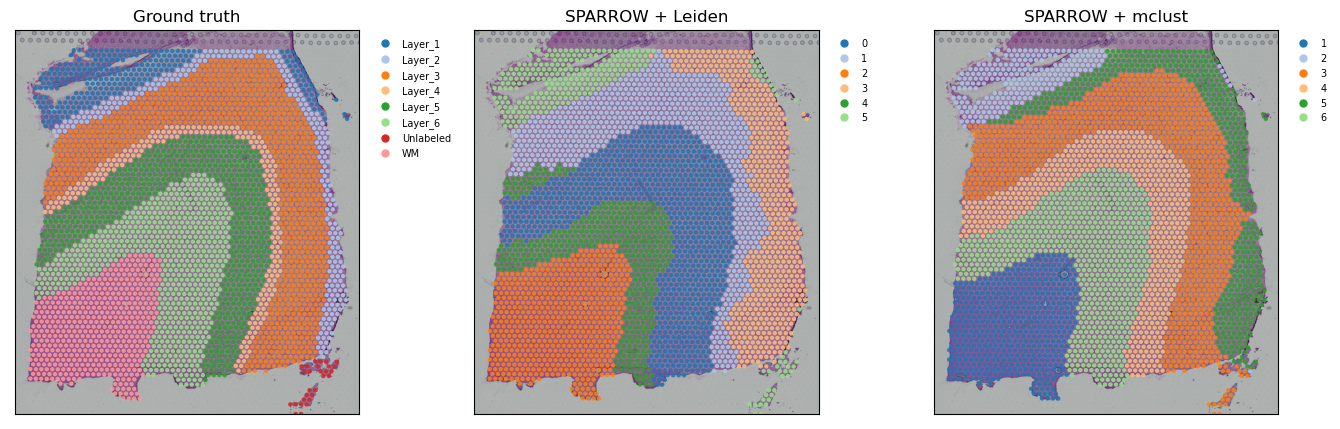

,ARI,NMI
SPARROW + Leiden,0.522058,0.646866
SPARROW + mclust,0.670384,0.749684


In [6]:
he_img = plt.imread(HE_IMAGE_PATH)
with open(SCALEFACTORS_PATH, "r") as f:
    hires_scale = json.load(f).get("tissue_hires_scalef", 1.0)

coords_he = adata.obs[["x_pixel", "y_pixel"]].to_numpy(dtype=float) * hires_scale
coords_he = coords_he[:, [1, 0]]
plot_keys = [GROUP_KEY, "SPARROW_leiden", "SPARROW_mclust"]
plot_titles = ["Ground truth", "SPARROW + Leiden", "SPARROW + mclust"]

x_min, x_max = np.nanpercentile(coords_he[:, 0], [0.5, 99.5])
y_min, y_max = np.nanpercentile(coords_he[:, 1], [0.5, 99.5])
pad = 80

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6))
for ax, key, title in zip(axes, plot_keys, plot_titles):
    values = adata.obs[key].astype("object").fillna("Unlabeled").astype("category")
    palette = sns.color_palette("tab20", n_colors=max(len(values.cat.categories), 1))
    color_map = dict(zip(values.cat.categories, palette))
    point_colors = [color_map[v] for v in values]

    ax.imshow(he_img)
    ax.scatter(coords_he[:, 0], coords_he[:, 1], c=point_colors, s=10, linewidths=0, alpha=0.88)
    ax.set_title(title)
    ax.set_xlim(max(x_min - pad, 0), min(x_max + pad, he_img.shape[1]))
    ax.set_ylim(min(y_max + pad, he_img.shape[0]), max(y_min - pad, 0))
    ax.set_xticks([])
    ax.set_yticks([])
    handles = [
        plt.Line2D([0], [0], marker="o", linestyle="", color=color_map[c], label=str(c), markersize=5)
        for c in values.cat.categories
    ]
    ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=7)

plt.tight_layout()
plt.show()

cluster_metrics = pd.DataFrame([leiden_metrics, mclust_metrics], index=["SPARROW + Leiden", "SPARROW + mclust"])
display(cluster_metrics)


## Deconvolution

This example reads the precomputed SPARROW deconvolution output for sample `151673` and displays the major cell-type proportions. The same deconvolution table is reused later in the A-to-I model.


In [7]:
df_deconv_raw = pd.read_csv(DECONV_PATH, index_col=0)
metadata_cols = {"in_tissue", "x_array", "y_array", "x_pixel", "y_pixel", "array_row", "array_col", GROUP_KEY, "domain"}
numeric_cols = df_deconv_raw.select_dtypes(include=[np.number]).columns.tolist()
celltype_cols = [c for c in numeric_cols if c not in metadata_cols]
celltype_cols = [c for c in celltype_cols if df_deconv_raw[c].notna().any() and df_deconv_raw[c].sum() > 0]

df_deconv = df_deconv_raw[celltype_cols].copy()
df_deconv = df_deconv.div(df_deconv.sum(axis=1).replace(0, np.nan), axis=0)

top_celltypes = df_deconv.mean(axis=0).sort_values(ascending=False).head(6).index.tolist()
common = adata.obs_names.intersection(df_deconv.index)
for col in top_celltypes:
    adata.obs[col] = np.nan
    adata.obs.loc[common, col] = df_deconv.loc[common, col].astype(float)

print("Precomputed deconvolution table:", df_deconv_raw.shape)
print("Cell-type proportion columns:", len(celltype_cols))
display(df_deconv[top_celltypes].describe().T)


Precomputed deconvolution table: (3639, 38)
Cell-type proportion columns: 33


,count,mean,std,min,25%,50%,75%,max
Ex_10_L2_4,3639.0,0.206251,0.212261,0.004052,0.046830,0.112653,0.312862,0.861294
Ex_3_L4_5,3639.0,0.110968,0.080021,0.000082,0.020349,0.128471,0.187871,0.246866
Ex_5_L5,3639.0,0.103770,0.082606,0.000000,0.008032,0.114547,0.174267,0.268322
Oligos_3,3639.0,0.099935,0.187446,0.000000,0.000084,0.000421,0.004386,0.488346
Ex_2_L5,3639.0,0.069529,0.058836,0.000000,0.000589,0.077391,0.121291,0.174735
Astros_2,3639.0,0.044538,0.065366,0.000084,0.001349,0.002699,0.110552,0.219779


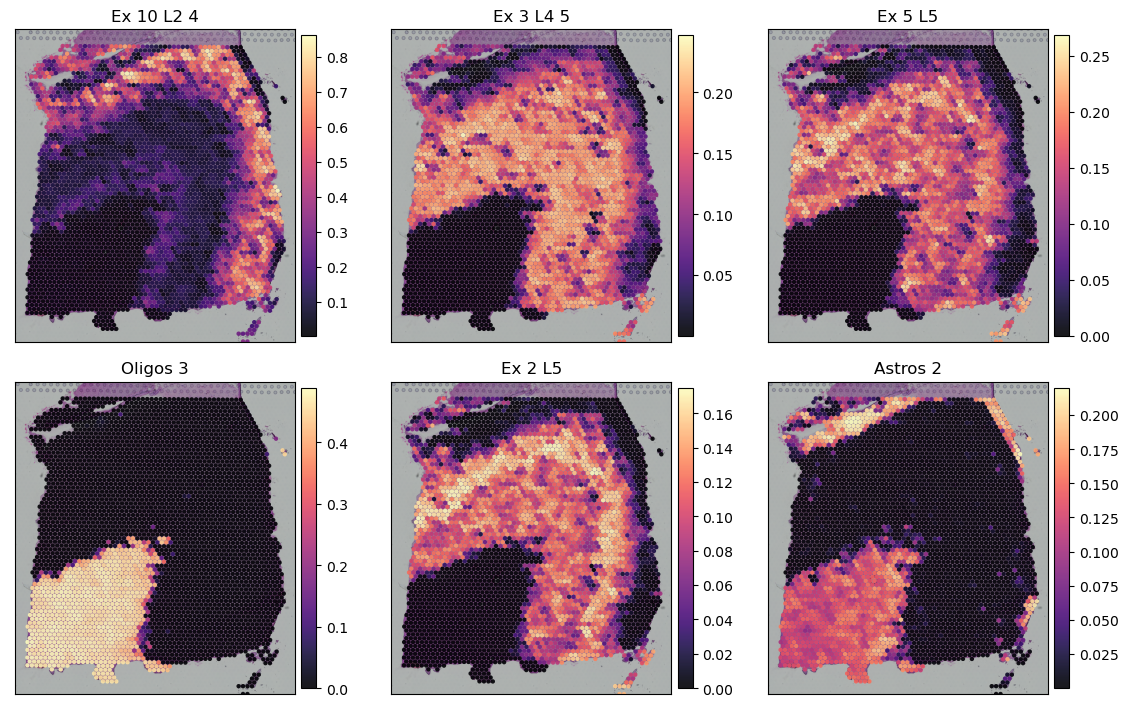

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.2))
axes = axes.ravel()
for ax, key in zip(axes, top_celltypes):
    values = pd.to_numeric(adata.obs[key], errors="coerce")
    ax.imshow(he_img)
    sc_plot = ax.scatter(coords_he[:, 0], coords_he[:, 1], c=values, s=10, cmap="magma", linewidths=0, alpha=0.9)
    ax.set_title(key.replace("_", " "))
    ax.set_xlim(max(x_min - pad, 0), min(x_max + pad, he_img.shape[1]))
    ax.set_ylim(min(y_max + pad, he_img.shape[0]), max(y_min - pad, 0))
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(sc_plot, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()


## Spatial A-to-I Editome

Load the A-to-I editing matrix, transfer spatial metadata, compute a global A-to-I score, inspect ADAR-family expression, and detect spatially variable A-to-I sites.


In [9]:

with open(SCALEFACTORS_PATH, "r") as f:
    spatial_scalefactors = json.load(f)
coordinate_scale = spatial_scalefactors.get("tissue_hires_scalef", 1.0)

##  load adata
adata = sc.read_10x_h5(H5_PATH)
adata.X = adata.X.astype(np.float32)

tissue_positions = pd.read_csv(TISSUE_POSITIONS_PATH, header=None)
tissue_positions.columns = ["barcode", "in_tissue", "x_array", "y_array", "x_pixel", "y_pixel"]
tissue_positions = tissue_positions.set_index("barcode")
tissue_positions = tissue_positions.reindex(adata.obs_names)

adata.obs["in_tissue"] = tissue_positions["in_tissue"].values
adata.obs["x_array"] = tissue_positions["x_array"].values
adata.obs["y_array"] = tissue_positions["y_array"].values
adata.obs["x_pixel"] = tissue_positions["x_pixel"].values
adata.obs["y_pixel"] = tissue_positions["y_pixel"].values
adata.obs[["x_pixel", "y_pixel"]] = adata.obs[["x_pixel", "y_pixel"]].fillna(0)
adata.obsm["spatial"] = adata.obs[["x_pixel", "y_pixel"]].to_numpy(dtype=float)

label_df = pd.read_csv(LABEL_PATH)
label_df["barcode"] = label_df["key"].astype(str).str.split("_", n=1).str[1]
label_df = label_df.set_index("barcode")
adata.obs[GROUP_KEY] = adata.obs_names.map(label_df[GROUP_KEY])
adata.obs[GROUP_KEY] = adata.obs[GROUP_KEY].replace(["nan", "None", "NA", "null", ""], np.nan)

print(adata)
display(adata.obs[GROUP_KEY].value_counts(dropna=False).to_frame("n_spots"))

adata = atoi.set_spatial_background(
    adata,
    image_path=str(HE_IMAGE_PATH),
    swap_x_y=True,
    coordinate_scale=coordinate_scale,
    crop=True,
    crop_pad=120,
    image_alpha=0.78,
)


## load the adata_ai

adata_ai = sc.read_h5ad(ATOI_PATH)
adata_ai = atoi.transfer_obs_metadata(
    source_adata=adata,
    target_adata=adata_ai,
    columns=("x_pixel", "y_pixel", "x_array", "y_array", "in_tissue", GROUP_KEY),
)
adata_ai = atoi.set_spatial_background(
    adata_ai,
    image_path=str(HE_IMAGE_PATH),
    swap_x_y=True,
    coordinate_scale=coordinate_scale,
    crop=True,
    crop_pad=120,
    image_alpha=0.78,
)

print(adata_ai)
display(adata_ai.obs[[GROUP_KEY, "x_pixel", "y_pixel"]].head())


AnnData object with n_obs × n_vars = 3639 × 33538
    obs: 'in_tissue', 'x_array', 'y_array', 'x_pixel', 'y_pixel', 'ground_truth'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial'


,n_spots
Layer_3,989
Layer_6,692
Layer_5,673
WM,513
Layer_1,273
Layer_2,253
Layer_4,218
NaN,28


AnnData object with n_obs × n_vars = 3639 × 46103
    obs: 'x_pixel', 'y_pixel', 'x_array', 'y_array', 'in_tissue', 'ground_truth'
    var: 'chr', 'pos', 'Accession', 'Region', 'Position', 'Ref', 'Ed', 'Strand', 'db', 'type', 'dbsnp', 'repeat', 'Func.wgEncodeGencodeBasicV45', 'Gene.wgEncodeGencodeBasicV45', 'ExonicFunc.wgEncodeGencodeBasicV45', 'AAChange.wgEncodeGencodeBasicV45', 'Func.refGene', 'Gene.refGene', 'ExonicFunc.refGene', 'AAChange.refGene', 'Func.knownGene', 'Gene.knownGene', 'ExonicFunc.knownGene', 'AAChange.knownGene', 'phastConsElements100way', 'nSamples', 'nTissues', 'sTissue', 'sBody', 'nBodySites', 'PlotsBody', 'geneID', 'geneType', 'geneTag', 'uniprotID', 'rnacentral', 'nTCGASamples', 'nTCGAPrj', 'sTCGAprj', 'sTCGAdiseasetype', 'nTCGAdiseasetype', 'PlotsTCGA', 'PRIDE', 'REDInet_BS', 'REDInet_mean'
    uns: 'spatial_background'
    obsm: 'spatial'
    layers: 'A', 'G'


,ground_truth,x_pixel,y_pixel
ATAGGCGGCTATAGAA-1,Layer_6,7595,5046
GTAAGCGGGCAGTCAG-1,Layer_5,5214,7129
TTAAACAGAGTCCCGC-1,Layer_1,3518,4662
GGCGCTTCATTCCCTG-1,Layer_5,10489,7642
AACGCTGTTGCTGAAA-1,Layer_3,8943,9237


### Global A-to-I Score


In [10]:
adata_ai, keep_mask = atoi.filter_atoi_sites(
    adata_ai,
    min_spot_cov=5,
    min_n_spots=5,
    min_site_ratio=0,
    max_site_ratio=0.5,
    min_site_ratio_sd=None,
    copy=True,
    verbose=True,
)
adata_ai = atoi.set_spatial_background(
    adata_ai,
    image_path=str(HE_IMAGE_PATH),
    swap_x_y=True,
    coordinate_scale=coordinate_scale,
    crop=True,
    crop_pad=120,
    image_alpha=0.78,
)

global_score = atoi.compute_multisite_atoi_score(
    adata_ai,
    sites=None,
    score_name="global_atoi_score",
    min_cov=5,
    top_n=None,
    weight_col=None,
    require_sv=False,
    zscore_sites=True,
)

global_ratio = atoi.compute_global_atoi_ratio(
    adata_ai,
    ratio_key="global_atoi_ratio",
    coverage_key="global_atoi_cov",
    min_total_cov=10,
)

display(adata_ai.obs[["global_atoi_score", "global_atoi_score_n_sites", "global_atoi_ratio", "global_atoi_cov"]].describe())


Before: 46103
After : 59
Removed: 46044

Filtering criteria:
  site_G_ratio is not NaN
  site_G_ratio > 0
  site_G_ratio < 0.5
  n_spots_cov_gt5 >= 5


,global_atoi_score,global_atoi_score_n_sites,global_atoi_ratio,global_atoi_cov
count,714.000000,3639.000000,589.000000,3639.000000
mean,0.040696,0.247321,0.061823,12.794998
std,0.965905,0.558657,0.117842,43.515377
min,-2.229048,0.000000,0.002959,0.000000
25%,-0.562950,0.000000,0.015873,0.000000
50%,-0.260027,0.000000,0.027778,0.000000
75%,0.421897,0.000000,0.055556,2.000000
max,7.778673,5.000000,1.000000,696.000000


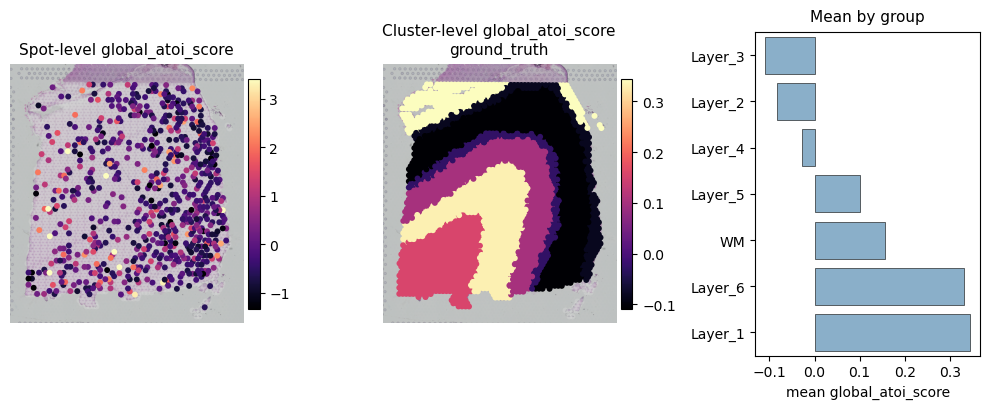

,count,mean,median,std
group,,,,
Layer_3,267,-0.108707,-0.356614,0.793353
Layer_2,67,-0.082560,-0.347558,0.949528
Layer_4,46,-0.028070,-0.221264,0.899776
Layer_5,132,0.100440,-0.264806,1.007359
WM,78,0.155549,0.001915,1.204018
Layer_6,95,0.330642,0.131718,1.091920
Layer_1,27,0.344029,0.034510,0.985379


In [11]:
fig, axes, global_summary = atoi.plot_cluster_level_obs_value(
    adata_ai,
    value_key="global_atoi_score",
    group_key=GROUP_KEY,
    cmap="magma",
)
plt.show()
display(global_summary)


### ADAR-Family Expression


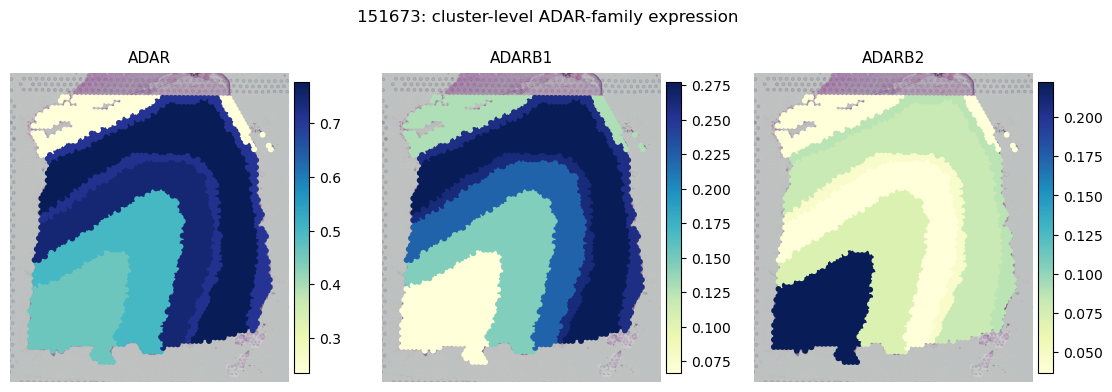

,expr_ADAR,expr_ADARB1,expr_ADARB2,expr_ADAR_family_score
count,3639.000000,3639.000000,3639.000000,3.639000e+03
mean,0.620500,0.197032,0.085738,2.233260e-17
std,0.874303,0.474103,0.322873,5.943676e-01
min,0.000000,0.000000,0.000000,-4.636146e-01
25%,0.000000,0.000000,0.000000,-4.636146e-01
50%,0.000000,0.000000,0.000000,-8.235873e-02
75%,1.000000,0.000000,0.000000,2.988972e-01
max,6.000000,4.000000,6.000000,5.730777e+00


In [12]:
added_adar_cols = atoi.add_gene_expression_to_obs(
    adata_expr=adata,
    target_adata=adata_ai,
    genes=ADAR_GENES,
    prefix="expr_",
    layer=None,
    log1p=False,
)

adar_family_score = atoi.add_obs_zmean_score(
    adata_ai,
    cols=added_adar_cols,
    score_name="expr_ADAR_family_score",
    min_nonmissing=1,
)

fig, axes, adar_cluster_summary = atoi.plot_cluster_level_obs_panel(
    adata_ai,
    value_keys=added_adar_cols,
    group_key=GROUP_KEY,
    cmap="YlGnBu",
    figsize=(11.4, 3.8),
    title=f"{SAMPLE_ID}: cluster-level ADAR-family expression",
)
plt.show()
display(adata_ai.obs[added_adar_cols + ["expr_ADAR_family_score"]].describe())


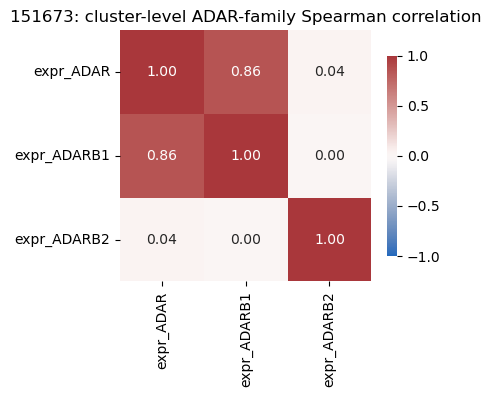

{'spot_corr':              expr_ADAR  expr_ADARB1  expr_ADARB2
 expr_ADAR     1.000000     0.075470     0.011685
 expr_ADARB1   0.075470     1.000000     0.007744
 expr_ADARB2   0.011685     0.007744     1.000000,
 'spot_p':              expr_ADAR  expr_ADARB1  expr_ADARB2
 expr_ADAR     0.000000     0.000005     0.481002
 expr_ADARB1   0.000005     0.000000     0.640516
 expr_ADARB2   0.481002     0.640516     0.000000,
 'cluster_mean':               expr_ADAR  expr_ADARB1  expr_ADARB2
 ground_truth                                     
 Layer_1        0.234432     0.128205     0.036630
 Layer_2        0.707510     0.256917     0.086957
 Layer_3        0.776542     0.277048     0.081901
 Layer_4        0.715596     0.261468     0.045872
 Layer_5        0.745914     0.221397     0.037147
 Layer_6        0.500000     0.144509     0.070809
 WM             0.458090     0.066277     0.222222,
 'cluster_corr':              expr_ADAR  expr_ADARB1  expr_ADARB2
 expr_ADAR     1.000000     0.857

In [13]:
adar_corr = atoi.analyze_adar_spatial_correlation(
    adata_ai,
    adar_cols=added_adar_cols,
    group_key=GROUP_KEY,
    method="spearman",
    cluster_agg="mean",
)
fig, ax = atoi.plot_cluster_adar_correlation_heatmap(
    adar_corr,
    title=f"{SAMPLE_ID}: cluster-level ADAR-family Spearman correlation",
)
plt.show()
display(adar_corr)


### Cell-Type Modules and Joint Model

The A-to-I model reuses `df_deconv` from the deconvolution section.


Cell-type module terms used in the model: ['celltype_glial_module', 'celltype_excitatory_module']


,module,members,n_members
0,celltype_glial_module,"Astros_1, Astros_2, Astros_3, Micro/Macro, OPC...",9
1,celltype_excitatory_module,"Ex_10_L2_4, Ex_1_L5_6, Ex_2_L5, Ex_3_L4_5, Ex_...",10
2,celltype_inhibitory_module,"Inhib_1, Inhib_2_VIP, Inhib_3_SST, Inhib_4_SST...",8
3,celltype_vascular_module,Endo,1


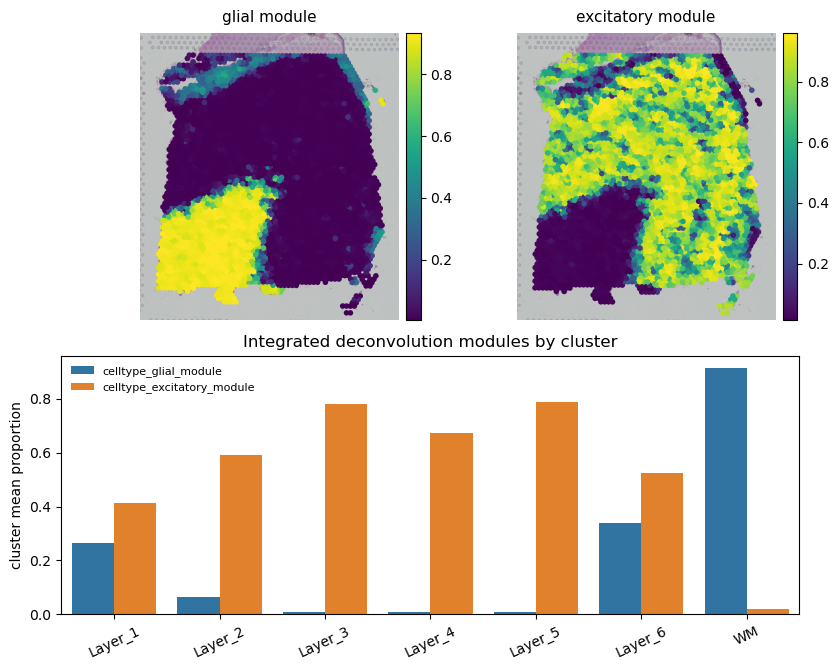

In [14]:
df_deconv, celltype_module_cols, celltype_module_members = atoi.add_celltype_composition_modules(
    df_deconv,
    prefix="celltype",
    normalize_modules=False,
)
celltype_model_cols = [c for c in ["celltype_glial_module", "celltype_excitatory_module"] if c in df_deconv.columns]
if not celltype_model_cols:
    celltype_model_cols = celltype_module_cols[:2]

print("Cell-type module terms used in the model:", celltype_model_cols)
display(celltype_module_members)

fig, axes, celltype_module_summary = atoi.plot_celltype_module_deconvolution_summary(
    adata_ai,
    df_deconv=df_deconv,
    module_cols=celltype_model_cols,
    group_key=GROUP_KEY,
    cluster_agg="mean",
    cmap="viridis",
    figsize=(8.5, 6.8),
)
plt.show()


,level,group_key,cluster_agg,n_spots,n_clusters,r2,adj_r2,residual_key,predictors,drop_reference,dropped_zero_var,condition_number
0,cluster,ground_truth,mean,NaN,7,0.226422,-0.160367,global_atoi_residual_celltype,"[celltype_glial_module, celltype_excitatory_mo...",None,[],7.049773


,level,group_key,cluster_agg,n_spots,n_clusters,r2,adj_r2,residual_key,predictors,drop_reference,dropped_zero_var,condition_number
0,cluster,ground_truth,mean,NaN,7,0.969249,0.938498,global_atoi_residual_celltype_adar,"[celltype_glial_module, celltype_excitatory_mo...",None,[],7.899644


,coef,pval,term,padj
0,0.101618,0.010163,const,0.020327
1,0.228993,0.047866,celltype_glial_module,0.063821
2,0.207289,0.066257,celltype_excitatory_module,0.066257
3,-0.183131,0.003405,expr_ADAR_family_score,0.013619


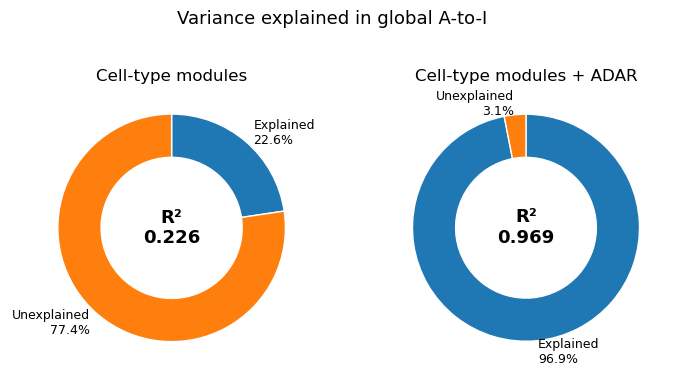

,model,R2,adjusted_R2,Unexplained,method
0,Cell-type modules,0.226422,-0.160367,0.773578,model_summary
1,Cell-type modules + ADAR,0.969249,0.938498,0.030751,model_summary


In [15]:
residual_celltype, fit_celltype, params_celltype, summary_celltype = atoi.fit_adjustment_model(
    adata_ai,
    score_key="global_atoi_score",
    predictors=celltype_model_cols,
    df_extra=df_deconv,
    covariates=(),
    residual_key="global_atoi_residual_celltype",
    min_complete=3,
    drop_reference=None,
    level="cluster",
    group_key=GROUP_KEY,
    cluster_agg="mean",
    store_key="cluster_celltype_only_global_atoi_model",
)

residual_joint, fit_joint, joint_params, joint_summary = atoi.fit_joint_atoi_model(
    adata_ai,
    df_deconv=df_deconv,
    score_key="global_atoi_score",
    celltype_cols=celltype_model_cols,
    adar_cols=["expr_ADAR_family_score"],
    covariates=(),
    residual_key="global_atoi_residual_celltype_adar",
    drop_reference=None,
    min_complete=3,
    level="cluster",
    group_key=GROUP_KEY,
    cluster_agg="mean",
    store_key="cluster_joint_global_atoi_model",
)

display(pd.DataFrame([summary_celltype]))
display(pd.DataFrame([joint_summary]))
display(joint_params)

fig, axes, r2_summary = atoi.plot_global_atoi_two_r2_donuts(
    adata_ai,
    celltype_store_key="cluster_celltype_only_global_atoi_model",
    joint_store_key="cluster_joint_global_atoi_model",
    use_model_summary=True,
    titles=("Cell-type modules", "Cell-type modules + ADAR"),
    figsize=(7.4, 3.6),
)
plt.show()
display(r2_summary)


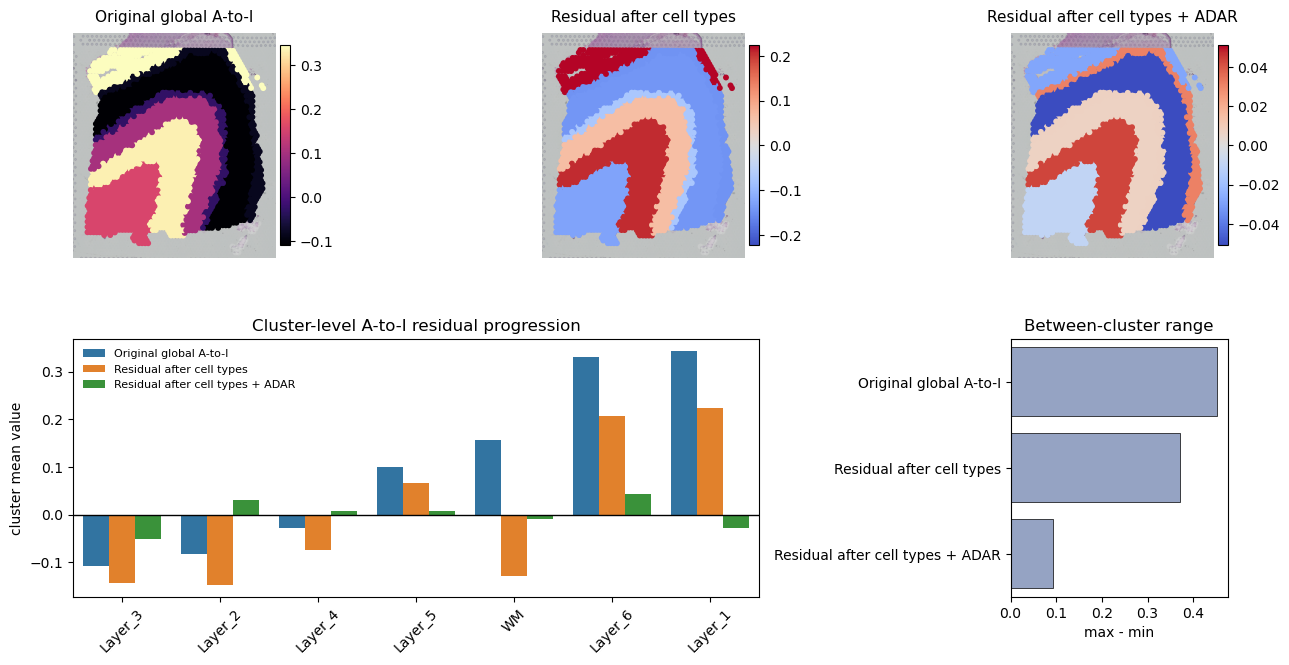

,group,metric,key,value
0,Layer_1,Original global A-to-I,global_atoi_score,0.344029
1,Layer_2,Original global A-to-I,global_atoi_score,-0.082560
2,Layer_3,Original global A-to-I,global_atoi_score,-0.108707
3,Layer_4,Original global A-to-I,global_atoi_score,-0.028070
4,Layer_5,Original global A-to-I,global_atoi_score,0.100440
5,Layer_6,Original global A-to-I,global_atoi_score,0.330642
6,WM,Original global A-to-I,global_atoi_score,0.155549
7,Layer_1,Residual after cell types,global_atoi_residual_celltype,0.223450
8,Layer_2,Residual after cell types,global_atoi_residual_celltype,-0.147874
9,Layer_3,Residual after cell types,global_atoi_residual_celltype,-0.144818


In [16]:
fig, axes, residual_progression_summary = atoi.plot_residual_progression(
    adata_ai,
    keys=("global_atoi_score", "global_atoi_residual_celltype", "global_atoi_residual_celltype_adar"),
    titles=("Original global A-to-I", "Residual after cell types", "Residual after cell types + ADAR"),
    group_key=GROUP_KEY,
    kind="bar",
    figsize=(13, 7.2),
)
plt.show()
display(residual_progression_summary)


### Spatially Variable A-to-I Sites


In [18]:
sample_id ="151673"
# Clear prior-run SV records for this sample before recomputing discovery.
for _name in ("sv_top_site_records", "wm_enrichment_records", "sv_annotation_records",
              "external_overlap_records", "external_overlap_summary_records", "mechanism_context_records"):
    globals()[_name] = [r for r in globals().get(_name, []) if r.get("sample_id") != sample_id]

sv_atoi = atoi.detect_spatial_atoi_sites_counts(
    adata_ai,
    n_knots="auto",  # or set a nonnegative integer manually
    knot_candidates=(0, 1, 2, 3, 4, 5),
    # Original positions preserve missing coordinates; plotting metadata may fill them with 0.
    spatial_coords=tissue_positions.reindex(adata_ai.obs_names)[["x_pixel", "y_pixel"]].to_numpy(dtype=float),
    min_cov=5,
    min_valid_spots=10,
    min_total_A=10,
    min_total_G=10,
    sv_call_by="p",  # unadjusted p-value criterion
    p_cutoff=0.05,
    fdr_cutoff=0.05,  # used when sv_call_by="fdr"
    verbose=True,
)

print("Selected K:", adata_ai.uns["sv_atoi_model_config"]["selected_n_knots"])
if "sv_atoi_k_selection" in adata_ai.uns:
    display(adata_ai.uns["sv_atoi_k_selection"])
display(sv_atoi.head(20))
display(sv_atoi["fit_status"].value_counts(dropna=False))
display(sv_atoi[["pass_qc", "is_sv_atoi"]].value_counts(dropna=False))


top_sv_table = atoi.summarize_top_sv_atoi_sites(
    sv_atoi,
    top_n=20,
    require_sv=True,
    store_in=adata_ai,
    store_key="top_sv_atoi_sites",
)

if top_sv_table.empty:
    print("No called SV-A-to-I sites under the current rule; showing top QC-passing spatial sites instead.")
    top_sv_table = atoi.summarize_top_sv_atoi_sites(
        sv_atoi,
        top_n=20,
        require_sv=False,
        store_in=adata_ai,
        store_key="top_sv_atoi_sites",
    )

top_sv_table = top_sv_table.copy()
top_sv_table["sample_id"] = sample_id
sv_top_site_records = [
    r for r in sv_top_site_records
    if r.get("sample_id") != sample_id
]
sv_top_site_records.extend(top_sv_table.to_dict("records"))

print("Top SV-A-to-I site table:")
display(top_sv_table)


BIC selection: fitting K=0
BIC selection: fitting K=1
BIC selection: fitting K=2
BIC selection: fitting K=3
BIC selection: fitting K=4
BIC selection: fitting K=5
Selected shared K=0 from 7 common sites; p values conditional on selected K.
Selected K: 0


,n_knots,n_selection_sites,total_bic,selected
0,0,7,1355.880401,True
1,1,7,1372.085399,False
2,2,7,1393.992863,False
3,3,7,1420.389901,False
4,4,7,1441.484836,False
5,5,7,1463.821242,False


,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,fit_status,...,loglik_spatial,spatial_fdr,is_sv_atoi,sv_call_by,p_cutoff,fdr_cutoff,model_family,selected_n_knots,p_method,k_selection_site
0,17_16441808,SNHG29,14,468.0,70.0,538.0,0.086535,0.149856,True,ok,...,-53.422827,1.604233e-19,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False
1,17_16441790,SNHG29,14,294.0,93.0,387.0,0.224679,0.324572,True,ok,...,-107.330597,4.407620e-12,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False
2,1_634012,MIR12136;OR4F16,122,7200.0,146.0,7346.0,0.030810,0.041952,True,ok,...,-153.918693,1.835930e-08,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,True
3,7_5527424,ACTB,12,1814.0,22.0,1836.0,0.027285,0.060681,True,ok,...,-31.407487,2.473481e-03,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False
4,1_634046,MIR12136;OR4F16,48,3370.0,56.0,3426.0,0.021387,0.014736,True,ok,...,-56.045004,3.110642e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,True
5,7_5527386,ACTB,133,7289.0,146.0,7435.0,0.082470,0.088359,True,ok,...,-248.874769,3.110642e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,True
6,7_5527431,ACTB,27,2586.0,32.0,2618.0,0.022422,0.023942,True,ok,...,-37.015830,3.110642e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,True
7,1_169132308,ATP1B1,18,1729.0,20.0,1749.0,0.024257,0.028909,True,ok,...,-24.115168,3.110642e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False
8,1_634044,MIR12136;OR4F16,14,835.0,25.0,860.0,0.040650,0.036479,True,ok,...,-24.632774,6.178683e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False
9,17_16441776,SNHG29,20,709.0,152.0,861.0,0.276279,0.385990,True,ok,...,-273.031540,7.849398e-01,False,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False


insufficient_counts    37
ok                     22
Name: fit_status, dtype: int64

pass_qc  is_sv_atoi
False    False         37
True     False         18
         True           4
dtype: int64

Top SV-A-to-I site table:


,rank,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,...,spatial_fdr,is_sv_atoi,sv_call_by,p_cutoff,fdr_cutoff,model_family,selected_n_knots,p_method,k_selection_site,sample_id
0,1,17_16441808,SNHG29,14,468.0,70.0,538.0,0.086535,0.149856,True,...,1.604233e-19,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False,151673
1,2,17_16441790,SNHG29,14,294.0,93.0,387.0,0.224679,0.324572,True,...,4.407620e-12,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False,151673
2,3,1_634012,MIR12136;OR4F16,122,7200.0,146.0,7346.0,0.030810,0.041952,True,...,1.835930e-08,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,True,151673
3,4,7_5527424,ACTB,12,1814.0,22.0,1836.0,0.027285,0.060681,True,...,2.473481e-03,True,spatial_p,0.05,0.05,binomial,0,asymptotic_chi2_conditional_on_selected_k,False,151673


##### vis

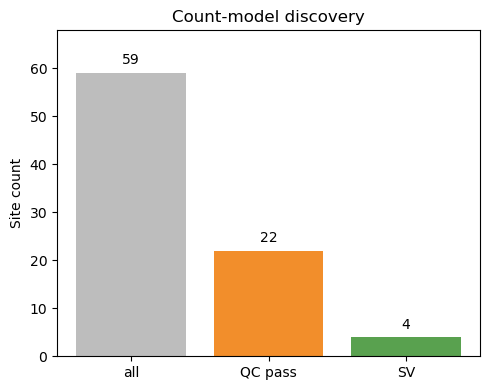

In [19]:
fig, axes = atoi.plot_count_spatial_discovery(
    sv_atoi,
)

plt.show()


#### Compute SV-A-to-I score

SV-A-to-I score sites: 4


,site,gene,is_sv_atoi,score_site_source,spatial_effect,spatial_p,spatial_fdr
0,17_16441808,SNHG29,True,called_sv_atoi,0.385780,7.291970e-21,1.604233e-19
1,17_16441790,SNHG29,True,called_sv_atoi,0.451395,4.006927e-13,4.407620e-12
2,1_634012,MIR12136;OR4F16,True,called_sv_atoi,0.051667,2.503541e-09,1.835930e-08
3,7_5527424,ACTB,True,called_sv_atoi,0.036935,4.497238e-04,2.473481e-03


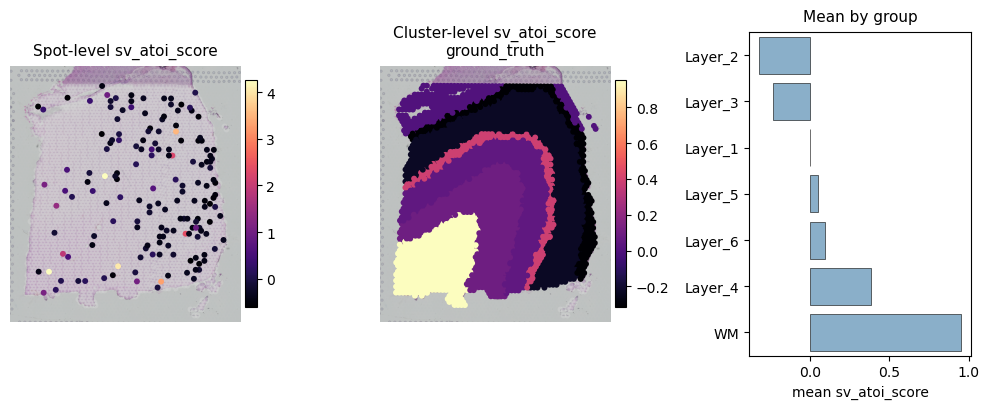

,count,mean,median,std
group,,,,
Layer_2,18,-0.317514,-0.372022,0.196597
Layer_3,56,-0.228804,-0.385897,0.670678
Layer_1,8,0.000388,0.031848,0.551447
Layer_5,32,0.050809,-0.252817,0.930306
Layer_6,20,0.094037,-0.159954,0.976705
Layer_4,14,0.386361,-0.126180,1.107589
WM,11,0.950995,0.148424,2.370594


In [20]:
# Remove stale scores if this rerun finds no raw-p-significant sites.
for _col in ("sv_atoi_score", "sv_atoi_score_n_sites"):
    if _col in adata_ai.obs:
        del adata_ai.obs[_col]
adata_ai.uns.pop("sv_atoi_score_site_table", None)
try:
    sv_score, sv_score_sites = atoi.compute_sv_atoi_score(
        adata_ai,
        sv_atoi=sv_atoi,
        score_name="sv_atoi_score",
        min_cov=5,
        top_n=200,
        weight_col="spatial_effect",
        require_sv=True,
        fallback_to_ranked=False,
        zscore_sites=True,
    )

    print("SV-A-to-I score sites:", len(sv_score_sites))
    display(sv_score_sites[["site", "gene", "is_sv_atoi", "score_site_source", "spatial_effect", "spatial_p", "spatial_fdr"]].head(20))

    fig, axes, sv_score_summary = atoi.plot_cluster_level_obs_value(
        adata_ai,
        value_key="sv_atoi_score",
        group_key=GROUP_KEY,
        cmap="magma",
    )

    plt.show()
    display(sv_score_summary)

except ValueError as exc:
    print(f"Skip sv_atoi_score: {exc}")


#### Candidate and recurrent SV-A-to-I single-site spatial patterns


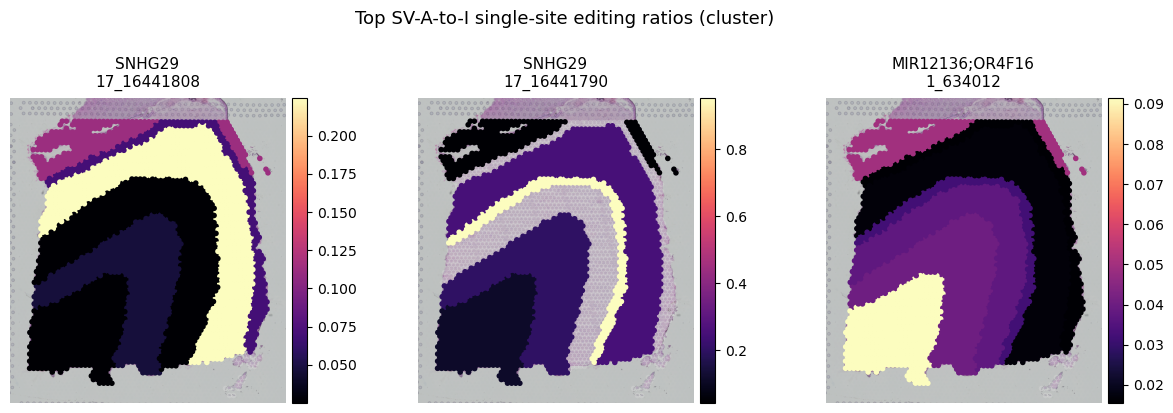

Recurrent SV-A-to-I anchor site: 1_634012


,sample_id,site,present_in_var,called_sv_atoi,spatial_effect,spatial_p,spatial_fdr,gene,n_wm,n_nonwm,mean_wm,mean_nonwm,wm_minus_nonwm,mannwhitney_u,pval
0,151673,1_634012,True,True,0.051667,2.503541e-09,1.835930e-08,MIR12136;OR4F16,8,114,0.09153,0.026549,0.064981,809.5,0.000261


In [22]:

if "is_sv_atoi" in sv_atoi.columns and sv_atoi["is_sv_atoi"].any():

    fig, axes = atoi.plot_top_sv_site_patterns(
        adata_ai,
        sv_atoi=sv_atoi,
        group_key=GROUP_KEY,
        top_n=3,
        min_cov=5,
        mode="cluster",
        cmap="magma",
    )

    plt.show()

else:
    print("No SV-A-to-I sites detected. Skip top-site cluster-level plots.")

if RECURRENT_SV_SITE in adata_ai.var_names:
    print(f"Recurrent SV-A-to-I anchor site: {RECURRENT_SV_SITE}")
    try:
        recurrent_ratio_df, recurrent_site_wm = atoi.analyze_single_site_wm_enrichment(
            adata_ai,
            site=RECURRENT_SV_SITE,
            group_key=GROUP_KEY,
            min_cov=5,
            wm_pattern=r"(?:^WM$|white)",
        )
        recurrent_ratio_df = recurrent_ratio_df.copy()
        recurrent_ratio_df["sample_id"] = sample_id
        recurrent_ratio_df["site"] = RECURRENT_SV_SITE
        recurrent_ratio_df["region"] = np.where(recurrent_ratio_df["is_wm"], "WM", "non-WM")

        recurrent_site_row = sv_atoi.loc[sv_atoi["site"] == RECURRENT_SV_SITE].copy()
        recurrent_site_record = {
            "sample_id": sample_id,
            "site": RECURRENT_SV_SITE,
            "present_in_var": True,
            "called_sv_atoi": bool(recurrent_site_row["is_sv_atoi"].iloc[0]) if not recurrent_site_row.empty and "is_sv_atoi" in recurrent_site_row.columns else False,
            "spatial_effect": float(recurrent_site_row["spatial_effect"].iloc[0]) if not recurrent_site_row.empty and pd.notna(recurrent_site_row["spatial_effect"].iloc[0]) else np.nan,
            "spatial_p": float(recurrent_site_row["spatial_p"].iloc[0]) if not recurrent_site_row.empty and pd.notna(recurrent_site_row["spatial_p"].iloc[0]) else np.nan,
            "spatial_fdr": float(recurrent_site_row["spatial_fdr"].iloc[0]) if not recurrent_site_row.empty and pd.notna(recurrent_site_row["spatial_fdr"].iloc[0]) else np.nan,
            "gene": recurrent_site_row["gene"].iloc[0] if not recurrent_site_row.empty and "gene" in recurrent_site_row.columns else "",
        }
        for col in recurrent_site_wm.columns:
            recurrent_site_record[col] = recurrent_site_wm[col].iloc[0]
        if "recurrent_site_records" not in globals():
            recurrent_site_records = []

        if "recurrent_site_ratio_records" not in globals():
            recurrent_site_ratio_records = []
        recurrent_site_records = [
            r for r in recurrent_site_records
            if not (r.get("sample_id") == sample_id and r.get("site") == RECURRENT_SV_SITE)
        ]
        recurrent_site_records.append(recurrent_site_record)

        recurrent_site_ratio_records = [
            r for r in recurrent_site_ratio_records
            if not (r.get("sample_id") == sample_id and r.get("site") == RECURRENT_SV_SITE)
        ]
        recurrent_site_ratio_records.extend(recurrent_ratio_df.to_dict("records"))

        display(pd.DataFrame([recurrent_site_record]))

    except ValueError as exc:
        print(f"Skip recurrent site WM summary: {exc}")
else:
    print(f"Recurrent anchor site {RECURRENT_SV_SITE} is not present in this sample's A-to-I matrix.")
    recurrent_site_records = [
        r for r in recurrent_site_records
        if not (r.get("sample_id") == sample_id and r.get("site") == RECURRENT_SV_SITE)
    ]
    recurrent_site_records.append({
        "sample_id": sample_id,
        "site": RECURRENT_SV_SITE,
        "present_in_var": False,
        "called_sv_atoi": False,
    })


#### Global vs SV-A-to-I comparison

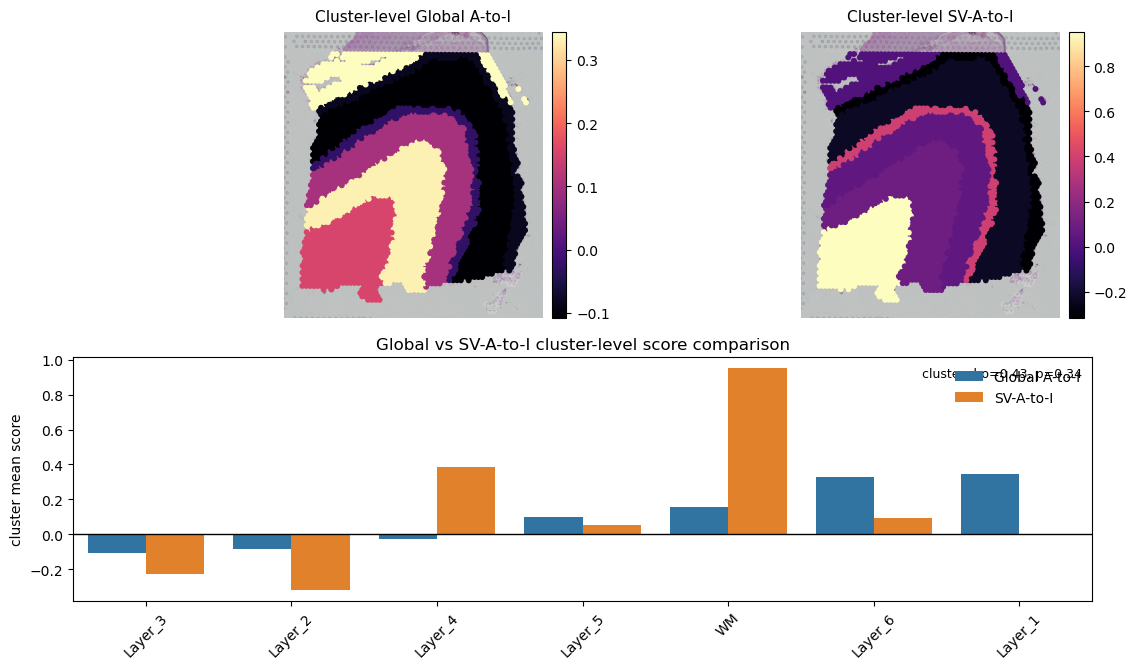

,group,score,score_key,value
0,Layer_1,Global A-to-I,global_atoi_score,0.344029
1,Layer_2,Global A-to-I,global_atoi_score,-0.082560
2,Layer_3,Global A-to-I,global_atoi_score,-0.108707
3,Layer_4,Global A-to-I,global_atoi_score,-0.028070
4,Layer_5,Global A-to-I,global_atoi_score,0.100440
5,Layer_6,Global A-to-I,global_atoi_score,0.330642
6,WM,Global A-to-I,global_atoi_score,0.155549
7,Layer_1,SV-A-to-I,sv_atoi_score,0.000388
8,Layer_2,SV-A-to-I,sv_atoi_score,-0.317514
9,Layer_3,SV-A-to-I,sv_atoi_score,-0.228804


SV-A-to-I score WM enrichment and external mechanism annotation
WM enrichment table; cross-sample panel only plots sv_atoi_score.


,feature,feature_type,level,n_wm,n_nonwm,mean_wm,mean_nonwm,wm_minus_nonwm,cohen_d,mannwhitney_u,pval,fdr,sample_id
0,sv_atoi_score,program_score,spot,11,148,0.950995,-0.064929,1.015924,1.035580,1196.5,0.009517,0.023792,151673
1,1_634012,site,spot,8,114,0.091530,0.026549,0.064981,1.663300,809.5,0.000261,0.001304,151673
2,17_16441808,site,spot,1,13,0.025000,0.091269,-0.066269,NaN,4.5,0.709510,0.893376,151673
3,17_16441790,site,spot,2,12,0.109890,0.243810,-0.133920,-0.386044,14.5,0.714701,0.893376,151673
4,7_5527424,site,spot,0,12,NaN,0.027285,NaN,NaN,NaN,NaN,1.000000,151673


Detected SV-A-to-I site annotation table:


,site,gene,n_valid_spots,total_A_valid,total_G_valid,total_cov_valid,mean_ratio,sd_ratio,pass_qc,fit_status,...,selected_n_knots,p_method,k_selection_site,Gene.refGene,Func.refGene,ExonicFunc.refGene,AAChange.refGene,repeat,host_gene,sample_id
0,17_16441808,SNHG29,14,468.0,70.0,538.0,0.086535,0.149856,True,ok,...,0,asymptotic_chi2_conditional_on_selected_k,False,SNHG29,ncRNA_exonic,-,-,SINE/AluJb,SNHG29,151673
1,17_16441790,SNHG29,14,294.0,93.0,387.0,0.224679,0.324572,True,ok,...,0,asymptotic_chi2_conditional_on_selected_k,False,SNHG29,ncRNA_exonic,-,-,SINE/AluJb,SNHG29,151673
2,1_634012,MIR12136;OR4F16,122,7200.0,146.0,7346.0,0.030810,0.041952,True,ok,...,0,asymptotic_chi2_conditional_on_selected_k,True,MIR12136;OR4F16,intergenic,-,-,-/-,MIR12136;OR4F16,151673
3,7_5527424,ACTB,12,1814.0,22.0,1836.0,0.027285,0.060681,True,ok,...,0,asymptotic_chi2_conditional_on_selected_k,False,ACTB,UTR3,-,-,-/-,ACTB,151673


...

,source,annotation_path,annotation_status,available,annotation_scope,n_sites,n_overlap_sites,n_site_annotation_links,n_unique_overlap_labels,overlap_count_definition,sample_id
0,miRBase,D:\data\SPARROW_data\Annotation\miRBase\hsa.gff3,loaded,True,direct_site_overlap,4,0,0,0,sum of matched annotation rows across queried ...,151673
1,miRGeneDB,D:\data\SPARROW_data\Annotation\miRGeneDB\hsa-...,loaded,True,direct_site_overlap,4,0,0,0,sum of matched annotation rows across queried ...,151673
2,RepeatMasker/Alu,D:\data\SPARROW_data\Annotation\RepeatMasker\r...,loaded,True,direct_site_overlap,4,2,2,1,sum of matched annotation rows across queried ...,151673
3,REDIportal,D:\data\SPARROW_data\Annotation\REDIportal\TAB...,loaded,True,direct_site_overlap,4,4,4,4,sum of matched annotation rows across queried ...,151673
4,TargetScan gene information,D:\data\SPARROW_data\Annotation\TargetScan\Gen...,loaded,True,human_gene_reference,4,2,2,2,sum of matched annotation rows across queried ...,151673
5,TargetScan miRNA families,D:\data\SPARROW_data\Annotation\TargetScan\miR...,loaded,True,reference_catalog_not_direct_site_overlap,4,0,0,0,sum of matched annotation rows across queried ...,151673
6,TargetScan predictions,D:\data\SPARROW_data\Annotation\TargetScan\Sum...,loaded,True,human_gene_miRNA_prediction,4,2,158,24,sum of matched annotation rows across queried ...,151673
7,RBP,D:\data\SPARROW_data\Annotation\RBP\ENCODE_eCL...,loaded,True,ENCODE_eCLIP_IDR_peaks_deduplicated_by_RBP,4,4,16,14,sum of matched annotation rows across queried ...,151673


Positive external evidence by site (RBP names are IDR-supported and deduplicated):


,sample_id,site,source,matched_gene,overlap_names,n_overlaps,n_raw_overlaps,annotation_scope
8,151673,17_16441808,RepeatMasker/Alu,NaN,AluJb,1,NaN,direct_site_overlap
9,151673,17_16441790,RepeatMasker/Alu,NaN,AluJb,1,NaN,direct_site_overlap
12,151673,17_16441808,REDIportal,NaN,EDHSAAXO9726,1,NaN,direct_site_overlap
13,151673,17_16441790,REDIportal,NaN,EDHSAAXO9720,1,NaN,direct_site_overlap
14,151673,1_634012,REDIportal,NaN,EDHSAAAA0642,1,NaN,direct_site_overlap
15,151673,7_5527424,REDIportal,NaN,EDHSABYZ7263,1,NaN,direct_site_overlap
18,151673,1_634012,TargetScan gene information,OR4F16,"olfactory receptor, family 4, subfamily F, mem...",1,NaN,human_gene_reference
19,151673,7_5527424,TargetScan gene information,ACTB,"actin, beta [Source:HGNC Symbol;Acc:132]",1,NaN,human_gene_reference
26,151673,1_634012,TargetScan predictions,OR4F16,hsa-miR-1253 | hsa-miR-2681-3p | hsa-miR-6770-...,4,NaN,human_gene_miRNA_prediction
27,151673,7_5527424,TargetScan predictions,ACTB,hsa-let-7g-3p | hsa-let-7i-3p | hsa-miR-1-3p |...,154,NaN,human_gene_miRNA_prediction


Mechanism-oriented context for detected SV-A-to-I sites:


,sample_id,site,host_gene,gene,Gene.refGene,regulatory_region_class,mirna_context,repeat_context,external_overlap_sources,n_external_evidence_types,mechanism_class,mechanism_note
0,151673,17_16441808,SNHG29,SNHG29,SNHG29,ncRNA,False,Alu/repeat-supported,RBP;REDIportal;RepeatMasker/Alu,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
1,151673,17_16441790,SNHG29,SNHG29,SNHG29,ncRNA,False,Alu/repeat-supported,RBP;REDIportal;RepeatMasker/Alu,3,multi-source evidence,Repeat/Alu context supports canonical ADAR dsR...
2,151673,1_634012,MIR12136;OR4F16,MIR12136;OR4F16,MIR12136;OR4F16,intergenic,True,annotated non-Alu/repeat,RBP;REDIportal;TargetScan gene information;Tar...,3,multi-source evidence,MIR-associated host annotation motivates nonco...
3,151673,7_5527424,ACTB,ACTB,ACTB,3UTR,True,annotated non-Alu/repeat,RBP;REDIportal;TargetScan gene information;Tar...,3,multi-source evidence,MIR-associated host annotation motivates nonco...


In [25]:
if "sv_atoi_score" in adata_ai.obs.columns:

    fig, axes, global_sv_summary = atoi.plot_cluster_score_comparison(
        adata_ai,
        score_keys=("global_atoi_score", "sv_atoi_score"),
        titles=("Global A-to-I", "SV-A-to-I"),
        group_key=GROUP_KEY,
        cmap="magma",
        figsize=(11.5, 6.8),
    )

    plt.show()
    display(global_sv_summary)

else:
    print("sv_atoi_score was not computed; skip global vs SV-A-to-I comparison.")


print("SV-A-to-I score WM enrichment and external mechanism annotation")

try:
    wm_enrichment = atoi.analyze_wm_enrichment_for_sv_sites(
        adata_ai,
        sv_atoi=sv_atoi,
        score_key="sv_atoi_score",
        group_key=GROUP_KEY,
        wm_pattern=r"(?:^WM$|white)",
        min_cov=5,
        top_n=20,
        require_sv=True,
        level="spot",
        store_key="wm_sv_atoi_enrichment",
    )
    wm_enrichment = wm_enrichment.copy()
    wm_enrichment["sample_id"] = sample_id
    wm_enrichment_records = [
        r for r in wm_enrichment_records
        if r.get("sample_id") != sample_id
    ]
    wm_enrichment_records.extend(wm_enrichment.to_dict("records"))

    print("WM enrichment table; cross-sample panel only plots sv_atoi_score.")
    display(wm_enrichment)

except ValueError as exc:
    print(f"Skip WM enrichment: {exc}")

try:
    sv_annotation = atoi.annotate_sv_atoi_sites(
        adata_ai,
        sv_atoi=sv_atoi,
        top_n=None,
        require_sv=True,
        store_key="sv_atoi_site_annotation",
    )
    sv_annotation = sv_annotation.copy()
    sv_annotation["sample_id"] = sample_id
    sv_annotation_records = [
        r for r in sv_annotation_records
        if r.get("sample_id") != sample_id
    ]
    sv_annotation_records.extend(sv_annotation.to_dict("records"))

    print("Detected SV-A-to-I site annotation table:")
    display(sv_annotation.head(40))

    external_detail, external_summary = atoi.run_sv_external_mechanism_overlaps(
        sv_annotation,
        annotation_paths=EXTERNAL_ANNOTATION_PATHS,
        site_col="site",
        flank=0,
        store_key="sv_external_mechanism_overlaps",
        adata_ai=adata_ai,
    )
    for _df in [external_detail, external_summary]:
        if not _df.empty:
            _df["sample_id"] = sample_id

    external_overlap_records = [
        r for r in external_overlap_records
        if r.get("sample_id") != sample_id
    ]
    external_overlap_summary_records = [
        r for r in external_overlap_summary_records
        if r.get("sample_id") != sample_id
    ]
    if not external_detail.empty:
        external_overlap_records.extend(external_detail.to_dict("records"))
    if not external_summary.empty:
        external_overlap_summary_records.extend(external_summary.to_dict("records"))

    mechanism_context = atoi.infer_sv_site_mechanism_context(
        sv_annotation,
        external_overlap_detail=external_detail,
        site_col="site",
    )
    if not mechanism_context.empty:
        mechanism_context["sample_id"] = sample_id
    mechanism_context_records = [
        r for r in mechanism_context_records
        if r.get("sample_id") != sample_id
    ]
    if not mechanism_context.empty:
        mechanism_context_records.extend(mechanism_context.to_dict("records"))

    print("External overlap summary. n_site_annotation_links is the sum of matched annotation rows across queried sites; gene-level links may repeat for sites sharing a host gene.")
    display(external_summary)
    positive_external_detail = external_detail.loc[external_detail["overlap"] == True].copy()
    if not positive_external_detail.empty:
        print("Positive external evidence by site (RBP names are IDR-supported and deduplicated):")
        display(positive_external_detail[[c for c in [
            "sample_id", "site", "source", "matched_gene", "overlap_names",
            "n_overlaps", "n_raw_overlaps", "annotation_scope"
        ] if c in positive_external_detail.columns]].head(120))
    print("Mechanism-oriented context for detected SV-A-to-I sites:")
    display(mechanism_context[[c for c in [
        "sample_id", "site", "host_gene", "gene", "Gene.refGene",
        "regulatory_region_class", "mirna_context", "repeat_context",
        "external_overlap_sources", "n_external_evidence_types", "mechanism_class", "mechanism_note"
    ] if c in mechanism_context.columns]].head(80))

except ValueError as exc:
    print(f"Skip SV annotation/external mechanism overlap: {exc}")
